In [1]:
from read_and_write.csv_handler import CSVHandler
from pathlib import Path

In [2]:
csv_io = CSVHandler(Path("test2"))

In [3]:
csv_io.get_relative_orbits()

{37, 88, 110, 161}

In [4]:
csv_io._meta

{'object_id_name': 'id',
 'mother_collection_id': '3a1834b72cda3452c5e4c5b41f178ed3fe8ef5fe068821267a09c9ac455b6eee',
 'variables': ['LIA_stdDev',
  'LIA_mean',
  'AZI_stdDev',
  'VV_mean',
  'AZI_mean',
  'VH_stdDev',
  'VH_mean',
  'VV_stdDev'],
 'properties': ['Usage', 'system:index', 'polygon_centroid', 'Name'],
 'orbits': [88, 37, 161, 110],
 'orbit_collection_names': {'88': 'S1_RO_88_Pass_ASC_Year_2024',
  '37': 'S1_RO_37_Pass_DES_Year_2024',
  '161': 'S1_RO_161_Pass_ASC_Year_2024',
  '110': 'S1_RO_110_Pass_DES_Year_2024'},
 'Orbit_88': ['S1_RO_88_Pass_ASC_Year_2024_1of1.csv'],
 'Orbit_37': ['S1_RO_37_Pass_DES_Year_2024_1of1.csv'],
 'Orbit_161': ['S1_RO_161_Pass_ASC_Year_2024_1of1.csv'],
 'Orbit_110': ['S1_RO_110_Pass_DES_Year_2024_1of1.csv']}

In [5]:
csv_io.get_all_file_paths_per_orbit()

{88: {WindowsPath('test2/Orbit_88/S1_RO_88_Pass_ASC_Year_2024_1of1.csv')},
 161: {WindowsPath('test2/Orbit_161/S1_RO_161_Pass_ASC_Year_2024_1of1.csv')},
 37: {WindowsPath('test2/Orbit_37/S1_RO_37_Pass_DES_Year_2024_1of1.csv')},
 110: {WindowsPath('test2/Orbit_110/S1_RO_110_Pass_DES_Year_2024_1of1.csv')}}

In [17]:
ro_dss = []
for ro in csv_io.get_relative_orbits():
    red_orbit = csv_io.read_to_reduced_orbit(ro)
    ro_ds = red_orbit.create_dataset()
    ro_dss.append(ro_ds)

In [19]:
import xarray as xr


merged = xr.concat(
    ro_dss,
    dim="timestamp",
    data_vars="minimal",
    coords="minimal",
    compat="override",   # trust the first dataset's version of non-concat vars
    join="exact",        # make sure OID coords truly match across datasets
)

merged = merged.sortby("timestamp")
merged

<xarray.Dataset> Size: 33kB
Dimensions:       (OID: 4, timestamp: 120)
Coordinates:
  * OID           (OID) int64 32B 1 3 4 5
  * timestamp     (timestamp) datetime64[us] 960B 2024-01-01T06:00:00 ... 202...
Data variables: (12/14)
    VH_mean       (OID, timestamp) float64 4kB -14.18 -15.97 ... -16.26 -16.11
    LIA_stdDev    (OID, timestamp) float64 4kB 1.153 1.099 1.153 ... 1.532 1.337
    LIA_mean      (OID, timestamp) float64 4kB 40.63 33.53 31.8 ... 42.1 32.44
    VV_mean       (OID, timestamp) float64 4kB -5.125 -4.885 ... -11.08 -10.53
    VV_stdDev     (OID, timestamp) float64 4kB 1.581 1.71 1.982 ... 1.981 1.844
    AZI_mean      (OID, timestamp) float64 4kB 96.77 259.3 96.76 ... 96.77 259.3
    ...            ...
    RO            (timestamp) int64 960B 37 88 110 161 37 ... 88 110 161 37 88
    Name          (OID) object 32B 'L1' 'L3' 'L4' 'L5'
    Usage         (OID) object 32B 'Train' 'Test' 'Train' 'Test'
    system:index  (OID) int64 32B 3 1 2 0
    x             (OID) float64 32B 4.654 4.669 4.673 4.676
    y             (OID) float64 32B 50.87 50.87 50.86 50.86

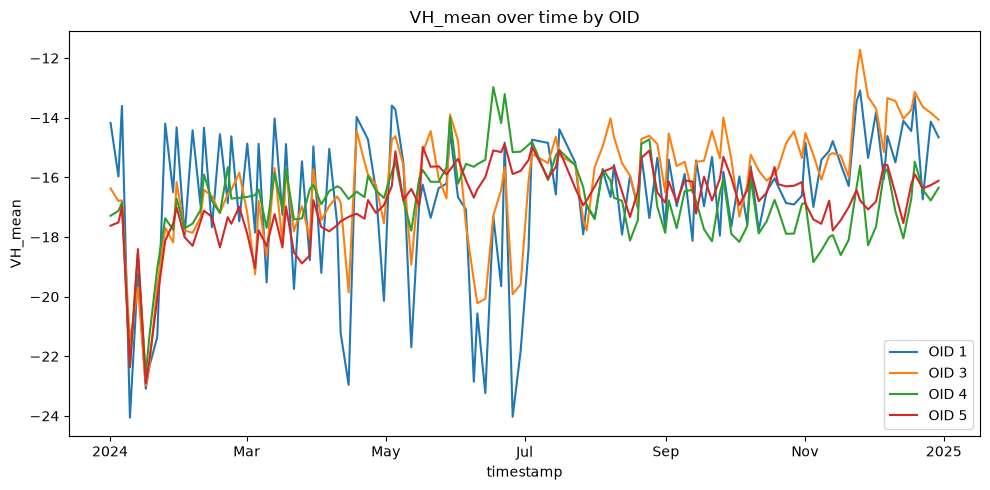

In [21]:
import matplotlib.pyplot as plt

# Plot VH_mean for each OID on the same axes
fig, ax = plt.subplots(figsize=(10, 5))

for oid in merged.OID.values:
    merged["VH_mean"].sel(OID=oid).plot(ax=ax, label=f"OID {oid}")

ax.set_title("VH_mean over time by OID")
ax.set_ylabel("VH_mean")
ax.legend()
plt.tight_layout()
plt.show()